# Indexing 2: point-by-point indexing (10 degree mosaicity)

Point-by-point (pbp) indexing with ImageD11: for every voxel of a grid in the
sample plane, the peaks whose diffraction path passes through that voxel are
indexed separately, and up to `gmax` candidate grains are kept per voxel.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os
import time

import numpy as np
import matplotlib.pyplot as plt
import ImageD11.cImageD11
import ImageD11.grain
import ImageD11.unitcell
import ImageD11.sinograms.point_by_point as pbp
from ImageD11.nbGui import nb_utils as utils
from simtools import dummy, io, paths, plot

plot.dark()

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"
colf = io.read_peaks(paths.peaks_path(SAMPLE))
print(f"{colf.nrows} peaks")

ypositions, ystep, ymin, y0 = dummy.add_pbp_columns(colf)
ny = len(ypositions)
nomega = len(np.unique(colf.omega))
print(f"{ny} translations with peaks, step {ystep:.5f} um, rotation axis at y0 = {y0}")

Reading your columnfile in hdf format


4872053 peaks


99 translations with peaks, step 0.10198 um, rotation axis at y0 = 0.0


In [3]:
pars = colf.parameters.parameters
ucell = ImageD11.unitcell.unitcell(
    [pars["cell__a"], pars["cell__b"], pars["cell__c"], pars["cell_alpha"], pars["cell_beta"], pars["cell_gamma"]],
    pars["cell_lattice_[P,A,B,C,I,F,R]"],
)
ucell.makerings(colf.ds.max())

In [4]:
savefile = os.path.join(paths.process_dir(SAMPLE), "peaks_2d")
dset = dummy.dset(colf.copy(), paths.PARFILE, savefile, ny, nomega)
assert dset.ymin == ymin
assert dset.ymax == ypositions[-1]
assert np.allclose(dset.ystep, ystep)
assert np.allclose(dset.ostep, 0.5)
dset.save()

## Parameters

In [5]:
percent_peaks_to_use = 99.99999  # strongest peaks used to generate trial orientations
eta_wedge = 6  # peaks within this many degrees of eta = 0 / 180 are not used
etacut = np.abs(np.sin(np.radians(eta_wedge)))
ifrac = np.percentile(colf.sum_intensity, 100 - percent_peaks_to_use) / colf.sum_intensity.max()
print(f"Using {percent_peaks_to_use}% of the peaks with intensity > {ifrac:.5f} * Imax")

pbpmanager = pbp.PBP(
    dset.parfile,
    dset,
    hkl_tol=0.07,  # peaks within this distance of integer hkl are assigned to a grain
    fpks=0.2,  # fraction of the predicted peaks a trial grain needs
    ds_tol=0.01,  # tolerance (1/A) on the ring assignment
    etacut=etacut,
    ifrac=ifrac,
    gmax=40,  # candidate grains kept per voxel
    cosine_tol=np.cos(np.radians(90 - dset.ostep)),
    y0=y0,
    symmetry="cubic",
    foridx=list(range(99)),  # rings used for indexing
    forgen=[0, 1],  # rings used to generate trial orientations
    uniqcut=0.2,
)
pbpmanager.setpeaks(colf.copy())

Using 99.99999% of the peaks with intensity > 0.00000 * Imax


0 0.4277 (1, 1, 1) 8 42927 used, sum_intensity> 1.0
1 0.4939 (2, 0, 0) 6 28894 used, sum_intensity> 0.6869197903869599
2 0.6985 (2, 0, 2) 12 64294 used, sum_intensity> 0.37815890816395026
3 0.8191 (1, 3, 1) 24 131078 used, sum_intensity> 0.25082382545359183
4 0.8555 (2, 2, 2) 8 47284 used, sum_intensity> 0.2219996909191098
5 0.9878 (0, 4, 0) 6 31677 used, sum_intensity> 0.12821081189930209
6 1.0765 (1, 3, 3) 24 144270 used, sum_intensity> 0.09587751655065727


7 1.1044 (4, 2, 0) 24 139951 used, sum_intensity> 0.11387133181082376
8 1.2098 (2, 4, 2) 24 152280 used, sum_intensity> 0.05509601020279141
9 1.2832 (3, 3, 3) 32 197104 used, sum_intensity> 0.053244646890693074
10 1.3970 (0, 4, 4) 12 80435 used, sum_intensity> 0.023560393313237872
11 1.4610 (1, 5, 3) 48 326214 used, sum_intensity> 0.023647810130672534
12 1.4817 (2, 4, 4) 30 206818 used, sum_intensity> 0.016727832421960978
13 1.5619 (6, 2, 0) 24 166605 used, sum_intensity> 0.011053544361693327


14 1.6194 (3, 5, 3) 24 172581 used, sum_intensity> 0.010532165486279462
15 1.6381 (2, 2, 6) 24 173239 used, sum_intensity> 0.007842537335566625
16 1.7110 (4, 4, 4) 8 60626 used, sum_intensity> 0.004923440039087805
17 1.7636 (5, 1, 5) 48 350314 used, sum_intensity> 0.005315254702946727
18 1.7808 (6, 4, 0) 24 176586 used, sum_intensity> 0.004981197579178563
19 1.8481 (2, 6, 4) 48 348961 used, sum_intensity> 0.0038479009817220804
20 1.8969 (3, 1, 7) 72 479399 used, sum_intensity> 0.0027348975740272147


21 1.9757 (0, 8, 0) 6 36509 used, sum_intensity> 0.0011660779039944804
22 2.0214 (7, 3, 3) 24 141214 used, sum_intensity> 0.0013971080643575098
23 2.0365 (2, 8, 0) 48 275606 used, sum_intensity> 0.0016328212685116819
24 2.0955 (8, 2, 2) 36 179820 used, sum_intensity> 0.0012363235608616177
25 2.1387 (5, 5, 5) 56 253448 used, sum_intensity> 0.0008382648386145059
26 2.1529 (2, 6, 6) 24 103251 used, sum_intensity> 0.0009537799187960207
27 2.2088 (4, 8, 0) 24 58061 used, sum_intensity> 0.0004089858244264442


28 2.2499 (1, 1, 9) 72 131074 used, sum_intensity> 0.0003824485762766368
29 2.2634 (4, 2, 8) 48 78057 used, sum_intensity> 0.00027786059827445445
30 2.3167 (4, 6, 6) 24 21091 used, sum_intensity> 0.00016702856188408218
31 2.3558 (3, 1, 9) 48 38052 used, sum_intensity> 0.00014985740131655972
32 2.4197 (4, 8, 4) 24 9043 used, sum_intensity> 8.897783203170732e-05
33 2.4572 (3, 3, 9) 72 18098 used, sum_intensity> 6.712362767304237e-05
34 2.4696 (8, 0, 6) 30 8496 used, sum_intensity> 6.400159847894738e-05


35 2.5185 (8, 2, 6) 72 7212 used, sum_intensity> 4.9952467105519905e-05
36 2.5545 (1, 9, 5) 72 4047 used, sum_intensity> 2.9659277343902444e-05
37 2.5664 (2, 10, 2) 32 1974 used, sum_intensity> 2.8098262746854948e-05
38 2.6483 (9, 3, 5) 48 162 used, sum_intensity> 6.244058388189988e-06
39 2.6598 (8, 4, 6) 72 144 used, sum_intensity> 9.366087582284983e-06
40 2.7053 (4, 10, 2) 48 11 used, sum_intensity> 9.366087582284983e-06


Using for indexing: 4681353 npks, minpks, forgen 1410 282 [0, 1]


## Run

In [6]:
ImageD11.cImageD11.cimaged11_omp_set_num_threads(1)
grains_filename = savefile + "_pbpmap.h5"
if os.path.isfile(grains_filename):
    os.remove(grains_filename)
t0 = time.perf_counter()
pbpmanager.point_by_point(grains_filename, loglevel=3, gridstep=1, nprocs=len(os.sched_getaffinity(0)))
print(f"done in {time.perf_counter() - t0:.0f} s")

{'cosine_tol': np.float64(0.008726535498373897),
 'ds_tol': 0.01,
 'forgen': [0, 1],
 'hkl_tol': 0.07,
 'hmax': np.int64(10),
 'minpks': 282,
 'uniqcut': 0.2,
 'y0': np.float64(0.0),
 'ymin': np.float64(-4.9972339),
 'ystep': np.float64(0.10198436530612245)}


138.3494119644165 seconds 0.01411584654264019 s per point
138.34480571746826 seconds 0.014115376565398251 s per point without setup
done in 138 s


## Result

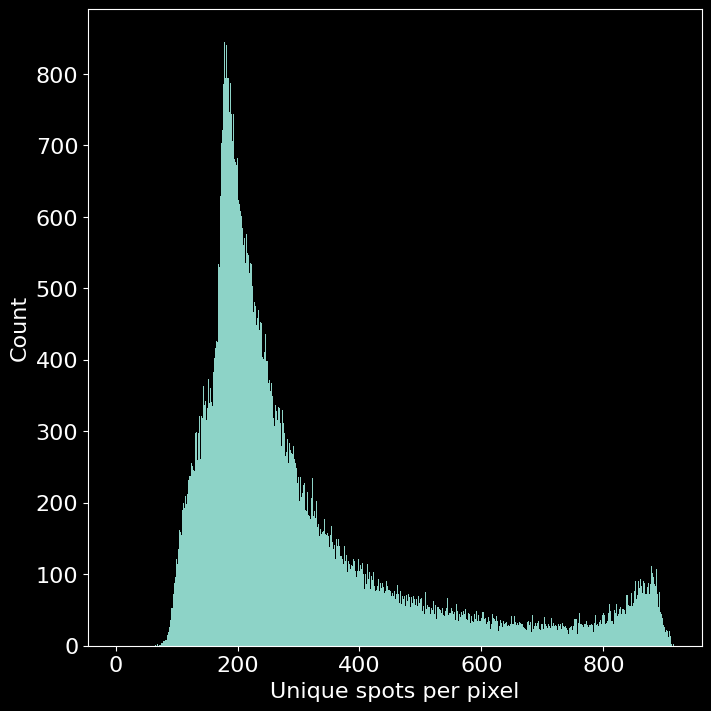

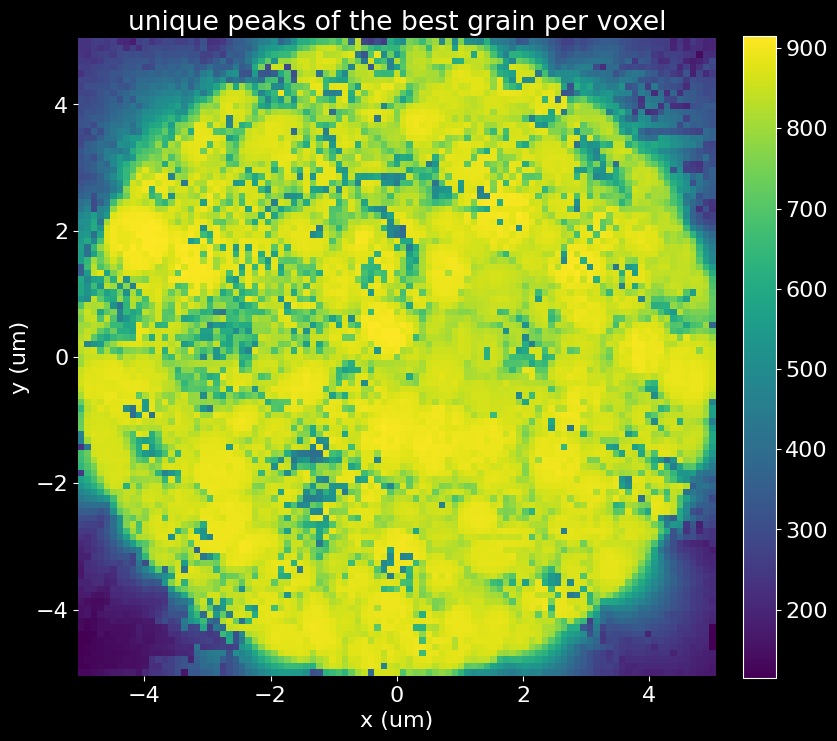

In [7]:
pbpmap = pbp.PBPMap(grains_filename)
pbpmap.plot_nuniq_hist()
pbpmap.choose_best(minpeaks=60)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))
im = ax.pcolormesh(dset.sx_grid, dset.sy_grid, pbpmap.best_nuniq)
ax.set_aspect("equal")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("unique peaks of the best grain per voxel")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plot.despine(ax)
plt.show()

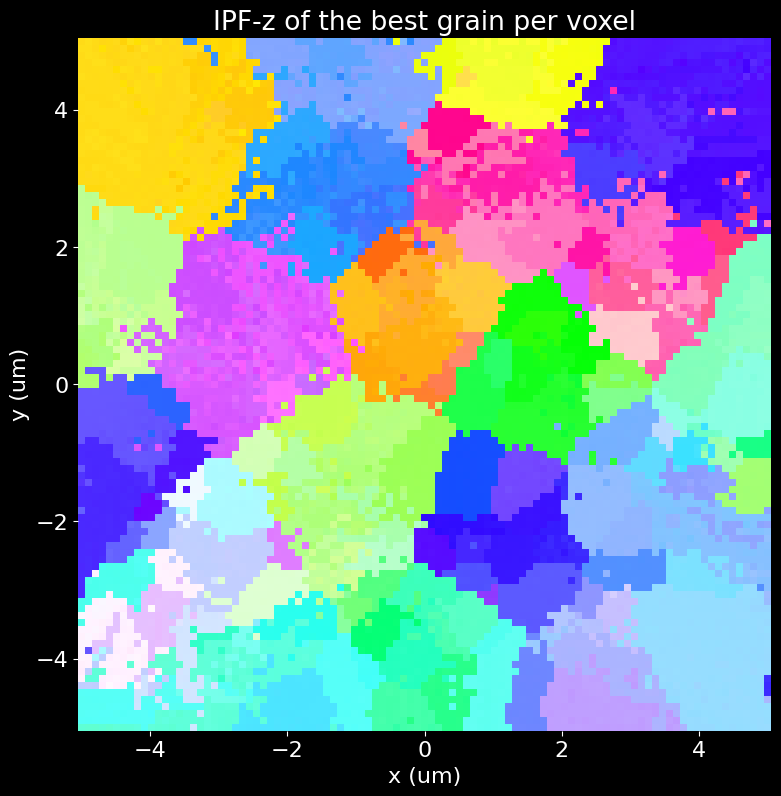

In [8]:
m = ~np.isnan(pbpmap.best_ubi[:, :, 0, 0])
grains = []
for ubi in pbpmap.best_ubi[m]:
    g = ImageD11.grain.grain(ubi)
    g.ref_unitcell = ucell
    grains.append(g)
utils.get_rgbs_for_grains(grains)
rgbmap = np.zeros((ny, ny, 3))
rgbmap[m] = [g.rgb_z for g in grains]

fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ax.pcolormesh(dset.sx_grid, dset.sy_grid, rgbmap)
ax.set_aspect("equal")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("IPF-z of the best grain per voxel")
plot.despine(ax)
plt.show()